## Import Libraries

In [ ]:
import pandas as pd # used for reading the CSV and handling tables (Dataframe)
import numpy as np # used for handling arrays(fast calculations) and numerical operations
import matplotlib.pyplot as plt # used for plotting graphs
import seaborn as sns # used for better-looking graphs and easier plotting that matplotlib


In [5]:
pd.set_option('display.max_columns', None) # Shows all columns when printing dataframes, without this -> some columns get hidden

## Load Dataset

In [6]:
df = pd.read_csv("../data/Salary_Data.csv") # Reads the CSV file and stores it in a DataFrame called df
df.head() # Prints the first 5 rows of the DataFrame to check if it loaded correctly

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Shape of Data

In [7]:
df.shape # Shows the number of rows and columns in the DataFrame in this case (6704, 6) -> 6704 rows(records) and 6 columns(features)

(6704, 6)

## Dataset Info

In [8]:
df.info() # Shows column names, data types (int, float, object), and non-null counts (if there are any missing values)

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 552.7 KB


## Missing Values

In [9]:
df.isnull().sum() # Shows the number of missing values in each column

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [10]:
df = df[df['Salary'].notnull()] # Removes rows where the Salary column has missing values, ensuring that all records have a salary value for analysis

In [11]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        1
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [12]:
df['Education Level'].unique()

<ArrowStringArray>
[       'Bachelor's',          'Master's',               'PhD',
 'Bachelor's Degree',   'Master's Degree',                 nan,
       'High School',               'phD']
Length: 8, dtype: str

In [13]:
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0]) # Alternative way to fill missing values in the Education Level column with the most common value (mode) in that column

In [14]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

## Statistical Summary

In [15]:
df.describe() # Shows summary statistics for numerical columns, including count, mean (average), std (standard deviation), min, 25th percentile, 50th percentile (median), 75th percentile, and max values for each numerical column in the DataFrame. This helps understand the distribution and range of the data.

,Age,Years of Experience,Salary
count,6699.000000,6699.000000,6699.000000
mean,33.622033,8.095014,115326.964771
std,7.615646,6.059853,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


## Column Names

In [16]:
df.columns # Shows the names of all columns in the DataFrame, useful when: 1) Selecting features, 2) Checking for debugging errors, 3) Understanding the dataset structure, 4) Referencing columns for analysis or visualization.

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

## Target Variable

In [17]:
df['Salary'].describe() # Focus on target variable (what to predict), Understand: 1) Average salary, 2) Salary range, 3) Salary distribution, 4) Potential outliers in salary data. This helps in understanding the target variable and informs decisions on data preprocessing and modeling.

count      6699.000000
mean     115326.964771
std       52786.183911
min         350.000000
25%       70000.000000
50%      115000.000000
75%      160000.000000
max      250000.000000
Name: Salary, dtype: float64

## Salary Distribution

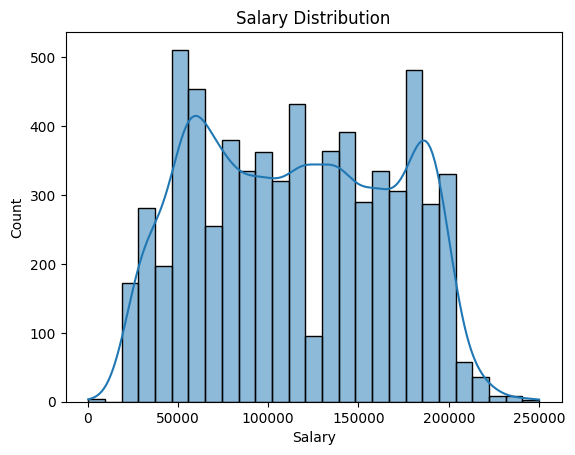

In [18]:
sns.histplot(df['Salary'], kde=True) # Plots a histogram of the Salary column with a kernel density estimate (KDE) to visualize the distribution of salaries in the dataset, helping to identify patterns, skewness, and potential outliers in salary data.
plt.title("Salary Distribution") # Adds a title to the plot
plt.show() # Displays the plot on the screen

## Experience vs Salary

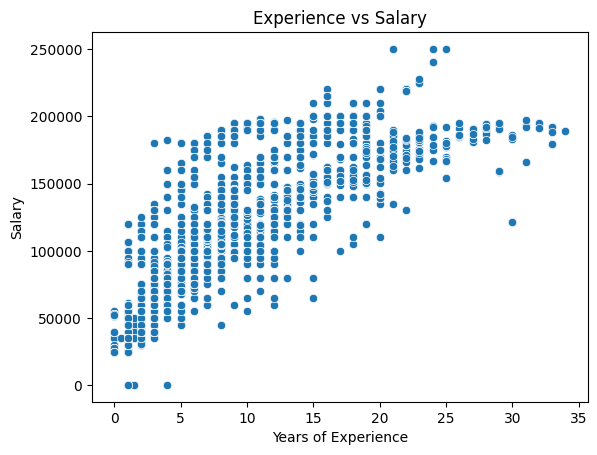

In [19]:
sns.scatterplot(x='Years of Experience', y='Salary', data=df) # Plots a scatter plot to visualize the relationship between years of experience and salary, which can help identify trends or correlations between these two variables.
plt.title("Experience vs Salary") # Adds a title to the scatter plot
plt.show() # Displays the scatter plot on the screen

### Categorical features Checking

In [20]:
df.select_dtypes(include='object').columns # Shows the names of all categorical columns (data type 'object') in the DataFrame, which is useful for identifying which features are categorical and may require encoding before modeling.

C:\Users\waqar\AppData\Local\Temp\ipykernel_34108\2603068693.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns # Shows the names of all categorical columns (data type 'object') in the DataFrame, which is useful for identifying which features are categorical and may require encoding before modeling.


Index(['Gender', 'Education Level', 'Job Title'], dtype='str')

## Salary by Job Role

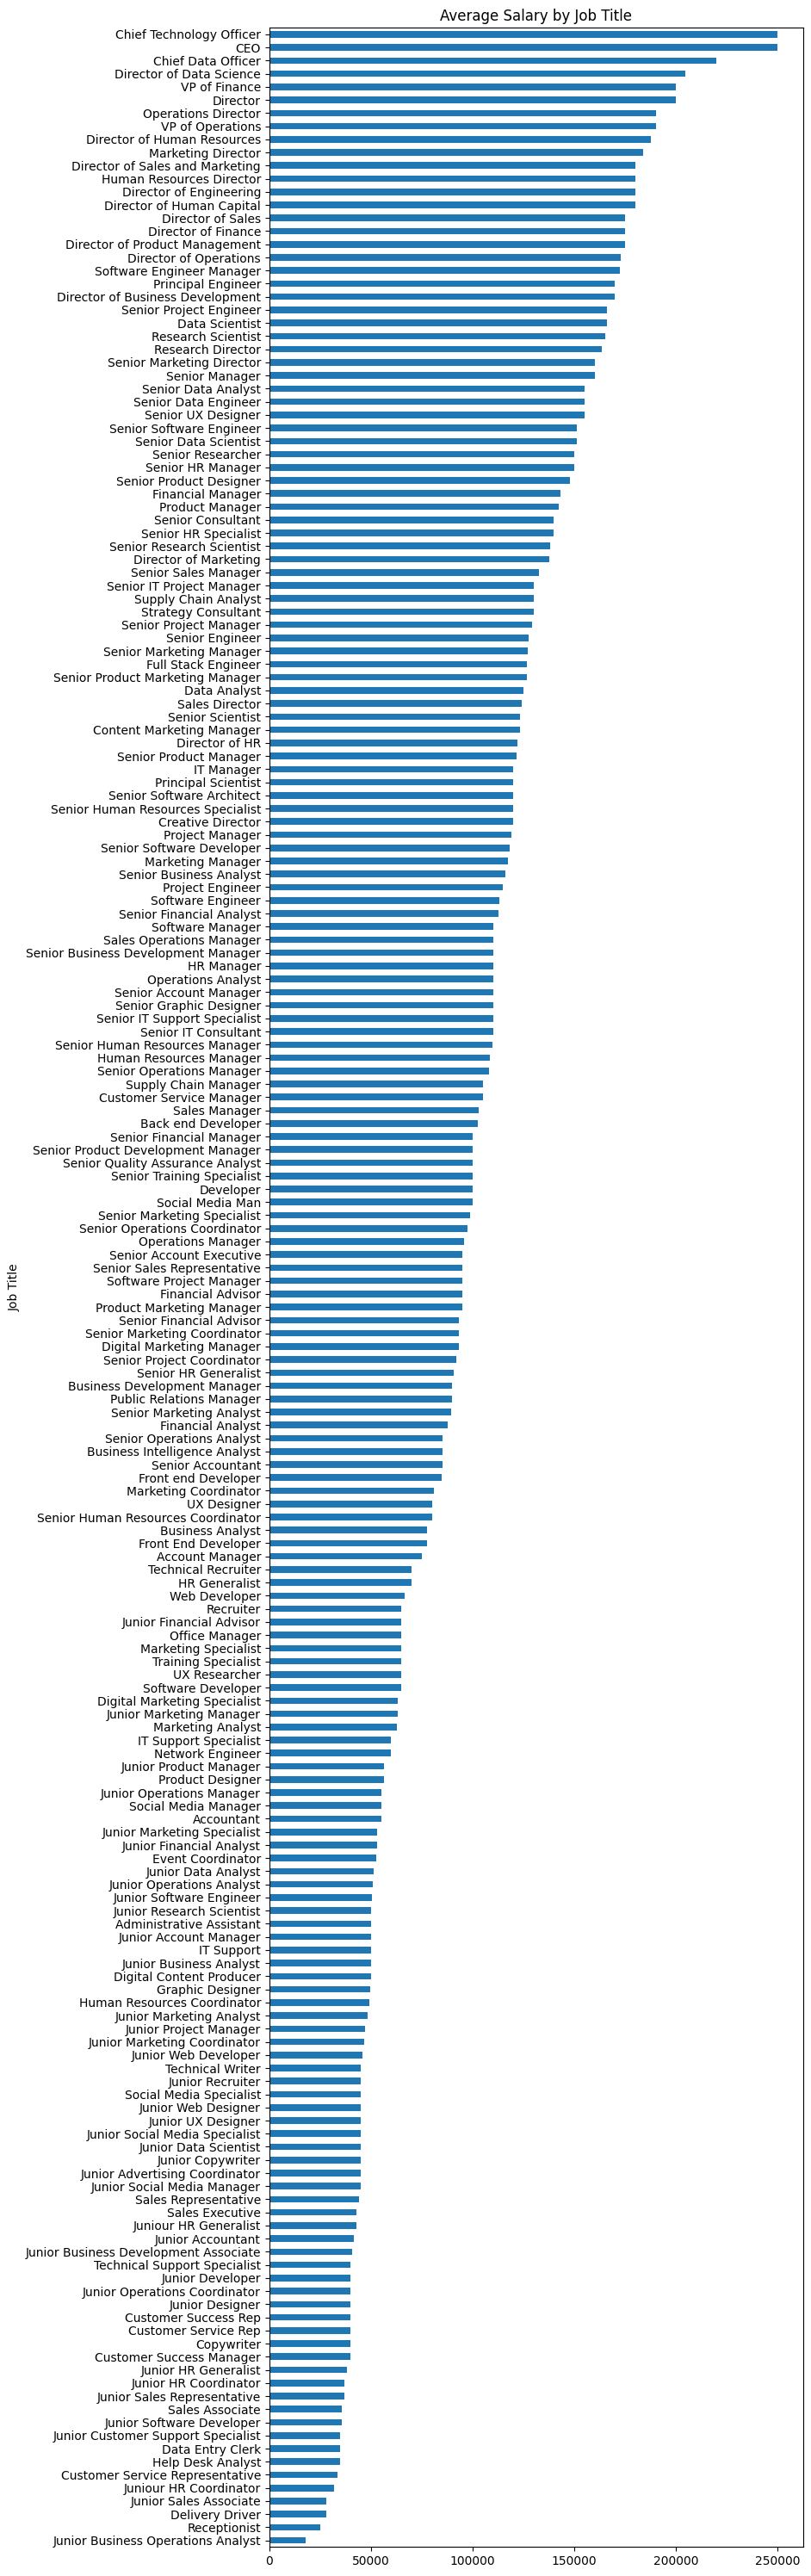

In [21]:
df.groupby('Job Title')['Salary'].mean().sort_values().plot(kind='barh', figsize=(8, 38)) # Plots a horizontal bar chart of average salary by job title, which helps visualize which job titles have higher or lower average salaries in the dataset.
plt.title("Average Salary by Job Title") # Adds a title to the bar chart
plt.show() # Displays the bar chart on the screen

## Separate the features (X) and target variable (y)

In [22]:
X = df.drop('Salary', axis=1) # Creates a new DataFrame X that contains all columns except 'Salary', which will be used as features for modeling
y = df['Salary'] # Creates a Series y that contains only the 'Salary' column, which will be used as the target variable for modeling

## Encode categorical variables

Machine Learning models cannot understand text, so we convert them into numbers.
We use Scikit-learn

In [23]:
from sklearn.preprocessing import OneHotEncoder # used for encoding categorical variables into numerical format

encoder = OneHotEncoder(drop='first', sparse_output=False) # Creates an instance of the OneHotEncoder with drop='first' to avoid multicollinearity and sparse_output=False to return a dense array instead of a sparse matrix

categorical_cols = X.select_dtypes(include='object').columns # Selects the names of all categorical columns in X to be encoded

encoded_categorical_data = encoder.fit_transform(X[categorical_cols]) # Fits the encoder to the categorical columns and transforms them into a numerical format


C:\Users\waqar\AppData\Local\Temp\ipykernel_34108\2314826717.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns # Selects the names of all categorical columns in X to be encoded


## Convert Encoded Data to DataFrame

In [24]:
encoded_df = pd.DataFrame(
    encoded_categorical_data,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
) # Converts the encoded categorical data into a DataFrame with appropriate column names and the same index as X to ensure proper alignment when concatenating

## Combine with Numerical Columns

In [25]:
X = X.drop(categorical_cols, axis=1) # Removes the original categorical columns from X

X = pd.concat([X, encoded_df], axis=1)

## Reset Indices

In [26]:
X = X.reset_index(drop=True) # Resets the index of X to ensure it is sequential and does not contain any gaps after dropping columns and concatenating
y = y.reset_index(drop=True) # Resets the index of y to ensure it is sequential and does not contain any gaps, aligning it with X for modeling

## Verify

In [27]:
print(X.shape) # Shows the number of rows and columns in X after encoding and concatenation, which helps verify that the data is in the correct format for modeling
print(y.shape) # Shows the number of rows in y, which should match the number of rows in X, confirming that the target variable is properly aligned with the features for modeling

(6699, 201)
(6699,)


## Check Final Data

In [28]:
X.head()

,Age,Years of Experience,Gender_Male,Gender_Other,Education Level_Bachelor's Degree,Education Level_High School,Education Level_Master's,Education Level_Master's Degree,Education Level_PhD,Education Level_phD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Back end Developer,Job Title_Business Analyst,Job Title_Business Development Manager,Job Title_Business Intelligence Analyst,Job Title_CEO,Job Title_Chief Data Officer,Job Title_Chief Technology Officer,Job Title_Content Marketing Manager,Job Title_Copywriter,Job Title_Creative Director,Job Title_Customer Service Manager,Job Title_Customer Service Rep,Job Title_Customer Service Representative,Job Title_Customer Success Manager,Job Title_Customer Success Rep,Job Title_Data Analyst,Job Title_Data Entry Clerk,Job Title_Data Scientist,Job Title_Delivery Driver,Job Title_Developer,Job Title_Digital Content Producer,Job Title_Digital Marketing Manager,Job Title_Digital Marketing Specialist,Job Title_Director,Job Title_Director of Business Development,Job Title_Director of Data Science,Job Title_Director of Engineering,Job Title_Director of Finance,Job Title_Director of HR,Job Title_Director of Human Capital,Job Title_Director of Human Resources,Job Title_Director of Marketing,Job Title_Director of Operations,Job Title_Director of Product Management,Job Title_Director of Sales,Job Title_Director of Sales and Marketing,Job Title_Event Coordinator,Job Title_Financial Advisor,Job Title_Financial Analyst,Job Title_Financial Manager,Job Title_Front End Developer,Job Title_Front end Developer,Job Title_Full Stack Engineer,Job Title_Graphic Designer,Job Title_HR Generalist,Job Title_HR Manager,Job Title_Help Desk Analyst,Job Title_Human Resources Coordinator,Job Title_Human Resources Director,Job Title_Human Resources Manager,Job Title_IT Manager,Job Title_IT Support,Job Title_IT Support Specialist,Job Title_Junior Account Manager,Job Title_Junior Accountant,Job Title_Junior Advertising Coordinator,Job Title_Junior Business Analyst,Job Title_Junior Business Development Associate,Job Title_Junior Business Operations Analyst,Job Title_Junior Copywriter,Job Title_Junior Customer Support Specialist,Job Title_Junior Data Analyst,Job Title_Junior Data Scientist,Job Title_Junior Designer,Job Title_Junior Developer,Job Title_Junior Financial Advisor,Job Title_Junior Financial Analyst,Job Title_Junior HR Coordinator,Job Title_Junior HR Generalist,Job Title_Junior Marketing Analyst,Job Title_Junior Marketing Coordinator,Job Title_Junior Marketing Manager,Job Title_Junior Marketing Specialist,Job Title_Junior Operations Analyst,Job Title_Junior Operations Coordinator,Job Title_Junior Operations Manager,Job Title_Junior Product Manager,Job Title_Junior Project Manager,Job Title_Junior Recruiter,Job Title_Junior Research Scientist,Job Title_Junior Sales Associate,Job Title_Junior Sales Representative,Job Title_Junior Social Media Manager,Job Title_Junior Social Media Specialist,Job Title_Junior Software Developer,Job Title_Junior Software Engineer,Job Title_Junior UX Designer,Job Title_Junior Web Designer,Job Title_Junior Web Developer,Job Title_Juniour HR Coordinator,Job Title_Juniour HR Generalist,Job Title_Marketing Analyst,Job Title_Marketing Coordinator,Job Title_Marketing Director,Job Title_Marketing Manager,Job Title_Marketing Specialist,Job Title_Network Engineer,Job Title_Office Manager,Job Title_Operations Analyst,Job Title_Operations Director,Job Title_Operations Manager,Job Title_Principal Engineer,Job Title_Principal Scientist,Job Title_Product Designer,Job Title_Product Manager,Job Title_Product Marketing Manager,Job Title_Project Engineer,Job Title_Project Manager,Job Title_Public Relations Manager,Job Title_Receptionist,Job Title_Recruiter,Job Title_Research Director,Job Title_Research Scientist,Job Title_Sales Associate,Job Title_Sales Director,Job Title_Sales Executive,Job Title_Sales Manager,Job Title_Sales Operations Manager,Job Title_Sales Representative,Job Titl

## Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split # used for splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Splits the data into training and testing sets, with 20% of the data used for testing and a fixed random state for reproducibility

### Train Model (Linear Regression)

In [ ]:
# from sklearn.linear_model import LinearRegression # used for creating a linear regression model
# model = LinearRegression() # Creates an instance of the LinearRegression model
# model.fit(X_train, y_train) # Fits the linear regression model to the training data (X_train and y_train), allowing it to learn the relationship between the features and the target variable (salary).

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
from sklearn.ensemble import RandomForestRegressor # used for creating a random forest regression model

model = RandomForestRegressor(n_estimators=100, random_state=42) # Creates an instance of the RandomForestRegressor with 100 trees and a fixed random state for reproducibility

model.fit(X_train, y_train) # Fits the random forest regression model to the training data (X_train and y_train), allowing it to learn the relationship between the features and the target variable (salary).

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Predictions

In [39]:
y_pred = model.predict(X_test) # Uses the fitted model to predict salary values for the test set (X_test), storing the predictions in y_pred for evaluation against the actual salary values in y_test.

### Evaluate Model

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # used for evaluating the performance of the model using different metrics
import numpy as np # used for handling arrays and numerical operations

mae = mean_absolute_error(y_test, y_pred) # Calculates the Mean Absolute Error (MAE) between the actual salary values (y_test) and the predicted salary values (y_pred), which measures the average magnitude of errors in the predictions.
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calculates the Root Mean Squared Error (RMSE) between the actual salary values (y_test) and the predicted salary values (y_pred), which measures the square root of the average squared differences between predictions and actual values, giving more weight to larger errors.
r2 = r2_score(y_test, y_pred) # Calculates the R-squared (R2) score, which represents the proportion of variance in the target variable (salary) that is explained by the features in the model. A higher R2 score indicates a better fit of the model to the data.

print(f"Mean Absolute Error: {mae}") # Prints the Mean Absolute Error (MAE) to the console
print(f"Root Mean Squared Error: {rmse}") # Prints the Root Mean Squared Error (RMSE) to the console
print(f"R-squared Score: {r2}") # Prints the R-squared (R2) score to the console

Mean Absolute Error: 2689.504543499298
Root Mean Squared Error: 6727.869060879829
R-squared Score: 0.984078478693636


### Bonus: Try Better Model

In [41]:
from sklearn.ensemble import RandomForestRegressor # used for creating a random forest regression model
rf = RandomForestRegressor() # Creates an instance of the RandomForestRegressor model, which is an ensemble learning method that builds multiple decision trees and averages their predictions to improve accuracy and control overfitting.
rf.fit(X_train, y_train) # Fits the random forest regression model to the training data (X_train and y_train), allowing it to learn the relationship between the features and the target variable (salary) using multiple decision trees.
y_pred_rf = rf.predict(X_test) # Uses the fitted random forest regression model to predict salary values for the test set (X_test), storing the predictions in y_pred_rf for evaluation against the actual salary values in y_test.
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred_rf)}") # Calculates and prints the R-squared (R2) score for the random forest model to evaluate its performance compared to the linear regression model.

Random Forest R2 Score: 0.9845649571104164


### Save Model

In [42]:
import joblib # used for saving and loading the model

joblib.dump(model, '../model.pkl') # Saves the linear regression model to a file named 'model.pkl' using joblib, allowing it to be loaded later for making predictions without needing to retrain the model.

['../model.pkl']

### Save Feature Columns

In [43]:
joblib.dump(X.columns.tolist(), '../columns.pkl') # Saves the column names of X to a file named 'columns.pkl' using joblib, which is important for ensuring that the same features are used when making predictions with the saved model in the future.

['../columns.pkl']

### Save Encoder

In [44]:
joblib.dump(encoder, '../encoder.pkl') # Saves the OneHotEncoder instance to a file named 'encoder.pkl' using joblib, allowing it to be loaded later for encoding new data in the same way as the training data when making predictions with the saved model.

['../encoder.pkl']

In [37]:
import os # used for handling file paths and directories
print(os.listdir('../')) # Lists the files in the parent directory to verify that the model, columns, and encoder files have been saved correctly.

['.venv', 'app.py', 'columns.pkl', 'data', 'encoder.pkl', 'model.pkl', 'notebooks', 'requirements.txt', 'src']
